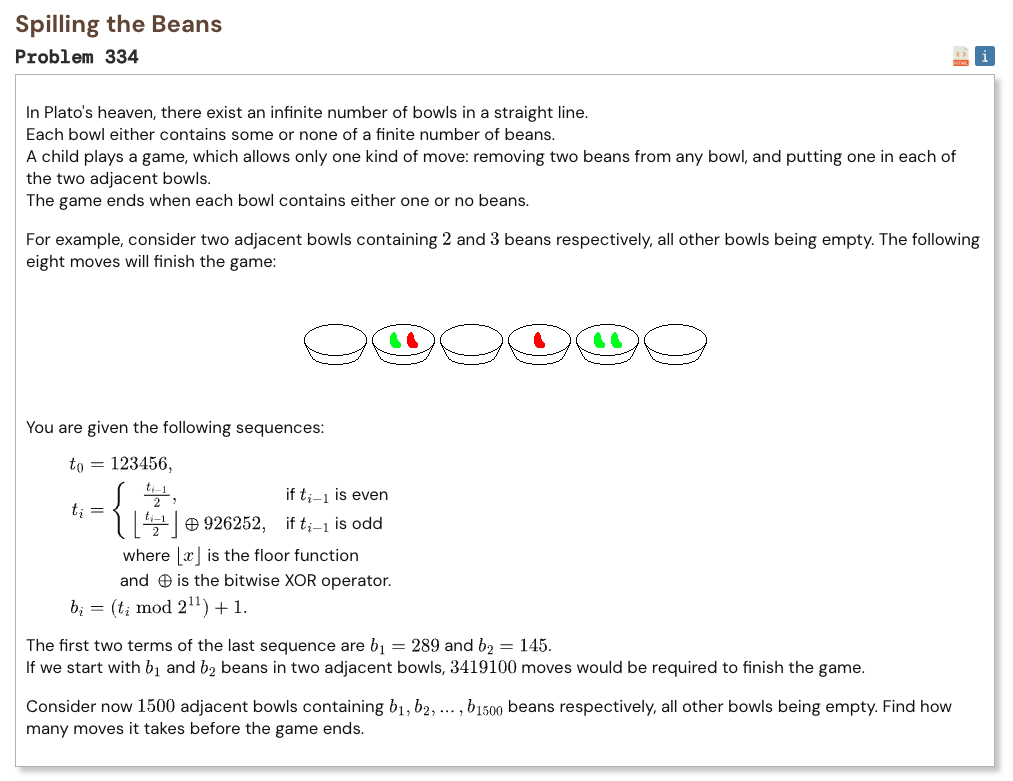

## Initial approach

* use the fact that the final board has only zero or one bean in each bowl
* the total number of beans never changes
* the weighted center of the beans never changes
* each move increases the second moment by exactly two
* so the total move count comes from the difference between final and initial second moments
* the final stable layout is the most compact set of occupied bowls with the same bean count and center
* compute that compact layout directly, without simulating the moves

In [1]:
def generate_beans(count):
    t = 123456
    beans = []

    for _ in range(count):
        if t % 2 == 0:
            t //= 2
        else:
            t = (t // 2) ^ 926252

        beans.append((t % (2 ** 11)) + 1)

    return beans

def final_second_moment(total_beans, center_sum):
    start = (center_sum - total_beans * (total_beans - 1) // 2) // total_beans
    base_sum = total_beans * start + total_beans * (total_beans - 1) // 2
    shift_count = center_sum - base_sum

    base_second = (
        total_beans * start * start
        + start * total_beans * (total_beans - 1)
        + total_beans * (total_beans - 1) * (2 * total_beans - 1) // 6
    )

    first_shifted = start + total_beans - shift_count
    shift_extra = shift_count * (2 * first_shifted + shift_count)

    return base_second + shift_extra

def moves_needed(beans):
    total_beans = sum(beans)
    center_sum = sum(i * value for i, value in enumerate(beans))
    initial_second = sum(i * i * value for i, value in enumerate(beans))

    final_second = final_second_moment(total_beans, center_sum)

    return (final_second - initial_second) // 2

def solve():
    beans = generate_beans(1500)
    return moves_needed(beans)

assert generate_beans(2) == [289, 145]
assert moves_needed([2, 3]) == 8
assert moves_needed(generate_beans(2)) == 3419100

In [2]:
%%time
result = solve()
print("Result:", result)

Result: 150320021261690835
CPU times: user 344 μs, sys: 3 μs, total: 347 μs
Wall time: 346 μs
